In [1]:
import pandas as pd
import numpy as np

In [2]:
#****************************************************#
#       Downloading and Formatting the Data          #
#****************************************************#

In [3]:
# Download Income Dataframe

income_df = pd.read_excel("/Users/ghadaelhusseini/Desktop/ZEW Interview Task/Income_Data_2023.xlsx")

In [4]:
income_df

,Regional-schlüssel,Gebietseinheit,Primäreinkommen der privaten Haushalte einschl. der privaten Organisationen ohne Erwerbszweck 2023
0,8,Baden-Württemberg,428393.279
1,81,"Stuttgart, Regierungsbezirk",167159.257
2,8111,"Stuttgart, Landeshauptstadt, Stadtkreis",27142.512
3,8115,"Böblingen, Landkreis",16387.836
4,8116,"Esslingen, Landkreis",21592.551
...,...,...,...
439,16054,"Suhl, Kreisfreie Stadt",921.356
440,16070,Ilm-Kreis,2802.306
441,16073,"Saalfeld-Rudolstadt, Landkreis",2580.594
442,16072,"Sonneberg, Landkreis",1435.312


In [5]:
income_df[income_df["Gebietseinheit"] == "Hamburg"]


,Regional-schlüssel,Gebietseinheit,Primäreinkommen der privaten Haushalte einschl. der privaten Organisationen ohne Erwerbszweck 2023
176,2,Hamburg,75054.041


In [6]:
# Some fornatting and preprocessing for the Income dataframe

income_df = income_df.rename(columns={"Regional-schlüssel": "Kreis Code"})
income_df.loc[income_df['Gebietseinheit'] == 'Berlin', 'Kreis Code'] = '11000'   #---> I change the Berlin code to match the rest of the indicators


/var/folders/4f/qxlwg6z95tgd3by8tpxwc6kh0000gn/T/ipykernel_82109/2531049153.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '11000' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  income_df.loc[income_df['Gebietseinheit'] == 'Berlin', 'Kreis Code'] = '11000'   #---> I change the Berlin code to match the rest of the indicators


In [7]:
# Download SGB_2 Dataframe
SGB_II_df = pd.read_excel('/Users/ghadaelhusseini/Desktop/ZEW Interview Task/SGB_II_2023 Data.xlsx')

In [8]:
# Some formatting and preprocessing for the Income dataframe

SGB_II_df.loc[SGB_II_df['regionaleinheit'] == 'Hamburg', 'Kreis Code'] = '00002' #---> I change the Hamburg code to match the rest of the indicators

/var/folders/4f/qxlwg6z95tgd3by8tpxwc6kh0000gn/T/ipykernel_82109/3609371246.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '00002' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  SGB_II_df.loc[SGB_II_df['regionaleinheit'] == 'Hamburg', 'Kreis Code'] = '00002' #---> I change the Hamburg code to match the rest of the indicators


In [9]:
# Download Educational_Attainment Dataframe

education_df = pd.read_excel('/Users/ghadaelhusseini/Desktop/ZEW Interview Task/School_Dropput__SHARE.xlsx')

In [10]:
# Some formatting and preprocessing for the Education dataframe

education_df = education_df.rename(columns={"Unnamed: 0": "Kreis Code"})
education_df = education_df.rename(columns={"Insgesamt.1": "Insgesamt ohne ersten schulabschluss"})
education_df = education_df.rename(columns={"% share ohne Ersten Schulabschluss\t(Absolvierende/Abgehende allgemeinbildender Schulen nach dem Abschluss\t\t\t)": "Absolvierende/Abgehende allgemeinbildender Schulen nach dem Abschluss ohne Ersten Schulabschluss % share"})

education_df.loc[education_df['Kreis'] == ' Berlin', 'Kreis Code'] = '11000' #---> I change the Berlin code to match the rest of the indicators

In [11]:
# Download Single_parents Dataframe

single_parents_df = pd.read_excel('/Users/ghadaelhusseini/Desktop/ZEW Interview Task/Alleinerziehenden Data.xlsx')

In [12]:
# Reformat the Single parents df


df = single_parents_df.copy()

# Find the row that actually holds the single-parent data
mask = df.iloc[:, 0].astype(str).str.strip() == "Alleinerziehende Elternteile"
data_row = df[mask].iloc[0]

# Kreis blocks start at column 1, repeating every 4 columns:
# [Anzahl, flag, Prozent, flag]
records = []
col_names = df.columns
ncols = df.shape[1]

for start in range(1, ncols, 4):
    kreis_name = col_names[start]
    if not isinstance(kreis_name, str) or kreis_name.startswith("Unnamed"):
        continue
    anzahl_raw = data_row.iloc[start]
    prozent_raw = data_row.iloc[start + 2] if start + 2 < ncols else np.nan
    records.append({
        "Kreis_raw": kreis_name,
        "Anzahl": anzahl_raw,
        "Prozent": prozent_raw
    })

single_parents_clean = pd.DataFrame(records)

# Split "01001 Flensburg, Stadt" into AGS code + Kreis name
single_parents_clean["AGS"] = single_parents_clean["Kreis_raw"].str.extract(r"^(\d+)")
single_parents_clean["Kreis"] = single_parents_clean["Kreis_raw"].str.replace(r"^\d+\s*", "", regex=True)

# Convert German number format ('.' = thousands sep, ',' = decimal sep) to floats
def clean_number(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x in ("-", ".", "", "None", "nan"):
        return np.nan
    x = x.replace(".", "").replace(",", ".")
    try:
        return float(x)
    except ValueError:
        return np.nan

single_parents_clean["Alleinerziehende_Anzahl"] = single_parents_clean["Anzahl"].apply(clean_number)
single_parents_clean["Alleinerziehende_Prozent"] = single_parents_clean["Prozent"].apply(clean_number)

single_parents_clean = single_parents_clean[
    ["AGS", "Kreis", "Alleinerziehende_Anzahl", "Alleinerziehende_Prozent"]
].dropna(subset=["Kreis"]).reset_index(drop=True)

single_parents_clean.head(10)

,AGS,Kreis,Alleinerziehende_Anzahl,Alleinerziehende_Prozent
0,01001,"Flensburg, Stadt",3906.0,18.2
1,01002,"Kiel, Landeshauptstadt",8820.0,15.8
2,01003,"Lübeck, Hansestadt",8368.0,16.3
3,01004,"Neumünster, Stadt",3341.0,16.5
4,01051,Dithmarschen,4953.0,13.3
5,01053,Herzogtum Lauenburg,7273.0,12.9
6,01054,Nordfriesland,6152.0,13.2
7,01055,Ostholstein,7050.0,12.2
8,01056,Pinneberg,11074.0,12.7
9,01057,Plön,4590.0,12.3


In [13]:
# Some further formatting and preprocessing for the Education dataframe

single_parents_clean = single_parents_clean.rename(columns={"AGS": "Kreis Code"})
single_parents_clean.loc[single_parents_clean['Kreis'] == 'Hamburg, Freie und Hansestadt', 'Kreis Code'] = '00002' #---> I change the Hamburg code to match the rest of the indicators


In [14]:
#***************************************************************#
#        Standardizing Kreis Names based on Kreis Code          #
#***************************************************************#

In [15]:
import pandas as pd

# --- Step 1: standardize the Kreis code column in each dataframe ---
def clean_code(df, code_col="Kreis Code"):
    df = df.copy()
    df[code_col] = (
        df[code_col]
        .astype(str)
        .str.strip()
      #  .str.replace(r"\.0$", "", regex=True)   # in case it was read as float, e.g. "7320.0"
        .str.zfill(5)                            # pad to 5 digits with leading zeros
    )
    return df

sgb2_df = clean_code(SGB_II_df)
education_df = clean_code(education_df)
income_df = clean_code(income_df)
single_parents_df = clean_code(single_parents_clean)

# quick sanity check — should all show 5-character codes like '07320'
for name, df in [("SGB II", sgb2_df), ("Education", education_df),
                  ("Income", income_df), ("Single parents", single_parents_df)]:
    print(name, df["Kreis Code"].str.len().value_counts())

SGB II Kreis Code
5    400
Name: count, dtype: int64
Education Kreis Code
5    524
8     15
Name: count, dtype: int64
Income Kreis Code
5    444
Name: count, dtype: int64
Single parents Kreis Code
5    400
Name: count, dtype: int64


In [16]:
#***************************************************************#
#        Merge All dataframes into one df                       #
#***************************************************************#

In [17]:
final_df = sgb2_df[["Kreis Code", "regionaleinheit", "SGB II-Quote bis Altersgrenze (%) 2023"]].copy()

final_df = final_df.merge(
    education_df[["Kreis Code", "Absolvierende/Abgehende allgemeinbildender Schulen nach dem Abschluss ohne Ersten Schulabschluss % share"]],
    on="Kreis Code", how="left"
)

final_df = final_df.merge(
    income_df[["Kreis Code", "Primäreinkommen der privaten Haushalte einschl. der privaten Organisationen ohne Erwerbszweck 2023"]],
    on="Kreis Code", how="left"
)

final_df = final_df.merge(
    single_parents_df[["Kreis Code", "Alleinerziehende_Anzahl", "Alleinerziehende_Prozent"]],
    on="Kreis Code", how="left"
)

final_df = final_df.rename(columns={"Kreis code": "AGS"})

final_df.head(10)

,Kreis Code,regionaleinheit,SGB II-Quote bis Altersgrenze (%) 2023,Absolvierende/Abgehende allgemeinbildender Schulen nach dem Abschluss ohne Ersten Schulabschluss % share,Primäreinkommen der privaten Haushalte einschl. der privaten Organisationen ohne Erwerbszweck 2023,Alleinerziehende_Anzahl,Alleinerziehende_Prozent
0,01001,Flensburg,12.6,8.498584,2497.633,3906.0,18.2
1,01002,Kiel,13.7,10.719755,7563.867,8820.0,15.8
2,01003,L√ºbeck,12.9,11.07438,6524.270,8368.0,16.3
3,01004,Neum√ºnster,13.2,12.688822,2172.780,3341.0,16.5
4,01051,Dithmarschen,9.2,11.538462,4318.153,4953.0,13.3
5,01053,Herzogtum Lauenburg,7.6,10.294118,7323.923,7273.0,12.9
6,01054,Nordfriesland,6.4,11.491935,6334.611,6152.0,13.2
7,01055,Ostholstein,6.5,10.877863,6825.601,7050.0,12.2
8,01056,Pinneberg,8.6,8.609959,12465.331,11074.0,12.7
9,01057,Pl√∂n,6.8,9.090909,4477.687,4590.0,12.3


In [18]:
final_df

,Kreis Code,regionaleinheit,SGB II-Quote bis Altersgrenze (%) 2023,Absolvierende/Abgehende allgemeinbildender Schulen nach dem Abschluss ohne Ersten Schulabschluss % share,Primäreinkommen der privaten Haushalte einschl. der privaten Organisationen ohne Erwerbszweck 2023,Alleinerziehende_Anzahl,Alleinerziehende_Prozent
0,01001,Flensburg,12.6,8.498584,2497.633,3906.0,18.2
1,01002,Kiel,13.7,10.719755,7563.867,8820.0,15.8
2,01003,L√ºbeck,12.9,11.07438,6524.270,8368.0,16.3
3,01004,Neum√ºnster,13.2,12.688822,2172.780,3341.0,16.5
4,01051,Dithmarschen,9.2,11.538462,4318.153,4953.0,13.3
...,...,...,...,...,...,...,...
395,16073,Saalfeld-Rudolstadt,7.8,8.994083,2580.594,4604.0,16.4
396,16074,Saale-Holzland-Kreis,5.1,8.625731,2304.502,3410.0,14.0
397,16075,Saale-Orla-Kreis,6.0,10.518732,2022.118,3305.0,14.9
398,16076,Greiz,5.9,10.705882,2438.808,3800.0,13.9


In [19]:
# Quick Check to see if there are any missing values

missing_count = final_df["Absolvierende/Abgehende allgemeinbildender Schulen nach dem Abschluss ohne Ersten Schulabschluss % share"].isna().sum()
print(f"\nTotal rows with missing values: {missing_count}")


Total rows with missing values: 0


In [20]:
#********************************************************************************#
#        Standardizing all the indicators using the Z-Score                      #
#********************************************************************************#

In [21]:
import numpy as np

indicators = [
    "Primäreinkommen der privaten Haushalte einschl. der privaten Organisationen ohne Erwerbszweck 2023",
    "SGB II-Quote bis Altersgrenze (%) 2023",
    "Alleinerziehende_Prozent",
    "Absolvierende/Abgehende allgemeinbildender Schulen nach dem Abschluss ohne Ersten Schulabschluss % share"
]

income_col = indicators[0]

df_z = final_df.copy()

# Manual z-score standardization, NaN-safe:
# mean/std are computed ignoring NaNs, but any NaN input stays NaN in the output
for col in indicators:
    mean = final_df[col].mean(skipna=True)
    std = final_df[col].std(skipna=True)
    df_z[col] = (final_df[col] - mean) / std

# Reverse income so higher = more vulnerable, consistent with the other indicators
df_z[income_col] = -df_z[income_col]

# Index is NaN if ANY of the 4 indicators is missing for that region
df_z["socioeconomic_index"] = df_z[indicators].mean(axis=1, skipna=False)

# Sanity check: how many regions get excluded
n_missing = df_z["socioeconomic_index"].isna().sum()
print(f"{n_missing} regions excluded due to missing indicator(s)")

0 regions excluded due to missing indicator(s)


In [22]:
# 1. Count how many NaN values are in the Socioeconomic column
missing_count = df_z["socioeconomic_index"].isna().sum()
print(f"Number of NaN values: {missing_count}")


Number of NaN values: 0


In [23]:
df_z

,Kreis Code,regionaleinheit,SGB II-Quote bis Altersgrenze (%) 2023,Absolvierende/Abgehende allgemeinbildender Schulen nach dem Abschluss ohne Ersten Schulabschluss % share,Primäreinkommen der privaten Haushalte einschl. der privaten Organisationen ohne Erwerbszweck 2023,Alleinerziehende_Anzahl,Alleinerziehende_Prozent,socioeconomic_index
0,01001,Flensburg,1.430773,0.367433,0.508909,3906.0,2.610415,1.229383
1,01002,Kiel,1.731011,1.183961,-0.034677,8820.0,1.277153,1.039362
2,01003,L√ºbeck,1.512656,1.314325,0.076867,8368.0,1.554916,1.114691
3,01004,Neum√ºnster,1.594539,1.907812,0.543765,3341.0,1.666021,1.428034
4,01051,Dithmarschen,0.502763,1.484927,0.313575,4953.0,-0.111661,0.547401
...,...,...,...,...,...,...,...,...
395,16073,Saalfeld-Rudolstadt,0.120641,0.549584,0.500008,4604.0,1.610469,0.695176
396,16074,Saale-Holzland-Kreis,-0.616308,0.414174,0.529632,3410.0,0.277207,0.151176
397,16075,Saale-Orla-Kreis,-0.370658,1.110062,0.559930,3305.0,0.777180,0.519129
398,16076,Greiz,-0.397952,1.178861,0.515221,3800.0,0.221655,0.379446


In [24]:
df_z[df_z["Kreis Code"] == "06415"]

,Kreis Code,regionaleinheit,SGB II-Quote bis Altersgrenze (%) 2023,Absolvierende/Abgehende allgemeinbildender Schulen nach dem Abschluss ohne Ersten Schulabschluss % share,Primäreinkommen der privaten Haushalte einschl. der privaten Organisationen ohne Erwerbszweck 2023,Alleinerziehende_Anzahl,Alleinerziehende_Prozent,socioeconomic_index


In [25]:
# Checking what region names where missing --> originally Hamburg and Berlin were missing due to mismatch in code names, but that was fixed
missing_region_names = df_z[df_z["socioeconomic_index"].isna()]["regionaleinheit"].unique()
missing_region_codes = df_z[df_z["socioeconomic_index"].isna()]["Kreis Code"].unique()

print("Regions with missing socioeconomic index:")
print(missing_region_names)

print("\nRegion codes with missing socioeconomic index:")
print(missing_region_codes)


Regions with missing socioeconomic index:
[]

Region codes with missing socioeconomic index:
[]


In [26]:
#*************************************#
#       Plotting the Geo Map          #
#*************************************#

In [27]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

In [28]:
import geopandas as gpd

gpkg = "/Users/ghadaelhusseini/Downloads/vg250_01-01.utm32s.gpkg.ebenen/vg250_ebenen_0101/DE_VG250.gpkg"

print(gpd.list_layers(gpkg))

              name geometry_type
0        vg250_vwg  MultiPolygon
1        vg250_sta  MultiPolygon
2        vg250_rbz  MultiPolygon
3         vg250_pk         Point
4         vg250_li    LineString
5        vg250_lan  MultiPolygon
6        vg250_krs  MultiPolygon
7        vg250_gem  MultiPolygon
8      v_vg250_gem  MultiPolygon
9      v_vg250_vwg  MultiPolygon
10     v_vg250_krs  MultiPolygon
11     v_vg250_rbz  MultiPolygon
12     v_vg250_lan  MultiPolygon
13     v_vg250_sta  MultiPolygon
14      v_vg250_li    LineString
15      v_vg250_pk         Point
16       v_vg250_f  MultiPolygon
17     v_vz250_gem  MultiPolygon
18          vg_lkz          None
19     vgtb_vz_gem          None
20     vgtb_rgs_vg          None
21    vgtb_rgs_otl          None
22     vgtb_azb_vg          None
23        vg_werte          None
24          vg_ibz          None
25        vg_daten          None
26         v_at_vg          None
27   v_vgtb_att_vg          None
28   v_vgtb_azb_vg          None
29   v_vgt

In [29]:
krs = gpd.read_file(
    gpkg,
    layer="vg250_krs"
)

print(krs.columns.tolist())

['OBJID', 'BEGINN', 'ADE', 'GF', 'BSG', 'LKZ', 'ARS', 'AGS', 'SDV_ARS', 'GEN', 'BEZ', 'IBZ', 'BEM', 'NBD', 'SN_L', 'SN_R', 'SN_K', 'SN_V1', 'SN_V2', 'SN_G', 'FK_S3', 'NUTS', 'ARS_0', 'AGS_0', 'WSK', 'DLM_ID', 'geometry']


In [30]:
merged_map = krs.merge(
    df_z,
    left_on="AGS",
    right_on="Kreis Code",
    how="left"
)

In [31]:
print(
    "Kreise without indicator:",
    merged_map["socioeconomic_index"].isna().sum()
)

Kreise without indicator: 3


In [32]:
missing = merged_map[
    merged_map["socioeconomic_index"].isna()
]

print(
    missing[["AGS", "GEN", "BEZ"]]
)

       AGS      GEN               BEZ
15   02000  Hamburg  Kreisfreie Stadt
120  06415    Hanau  Kreisfreie Stadt
414  02000  Hamburg  Kreisfreie Stadt


TypeError: Legend.__init__() got an unexpected keyword argument 'label'. Did you mean 'labels'?

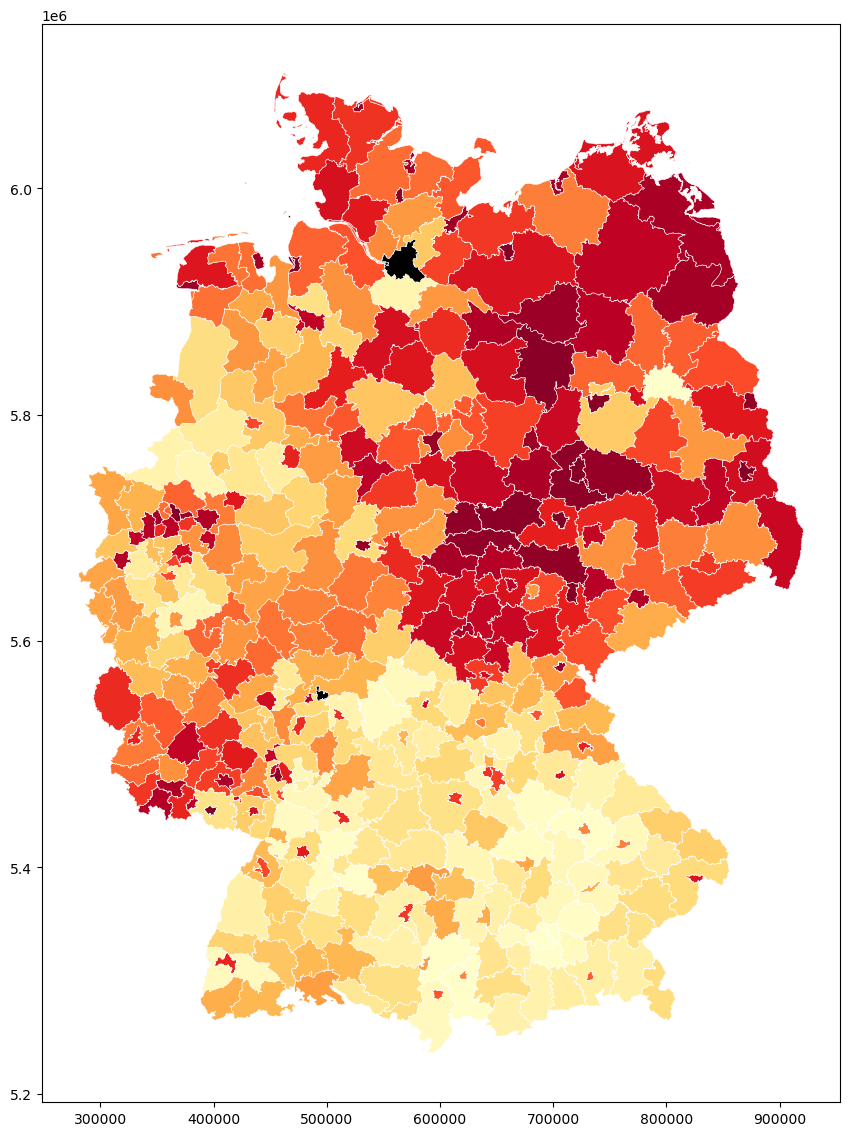

In [36]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 14))

# Plot the choropleth
merged_map.plot(
    column="socioeconomic_index",                 # <-- your indicator column
    cmap="YlOrRd",
    linewidth=0.4,
    edgecolor="white",
    legend=True,
    missing_kwds={
        "color": "black",
        "label": "No data"
    },
    ax=ax,
    legend_kwds={
        "label": "Socioeconomic vulnerability (higher = greater vulnerability)",
        "shrink": 0.7
    }
)

# --------------------------------------------------
# Add Kreis names
# --------------------------------------------------

for idx, row in merged_map.iterrows():

    point = row.geometry.representative_point()

    ax.annotate(
        text=row["GEN"],
        xy=(point.x, point.y),
        ha="center",
        va="center",
        fontsize=4,
        color="black"
    )

ax.set_axis_off()

plt.title(
    "Vulnerability Socioeconomic Indicator by Kreis, Germany",
    fontsize=16
)

plt.tight_layout()

# Save as high-quality vector PDF
plt.savefig(
    "germany_kreise_high_quality.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()